# project

Data file:
* https://raw.githubusercontent.com/xiangluna65-byte/CIS9660-project/refs/heads/main/StudentPerformanceFactors%20(2).csv

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
%cd "/content/gdrive/MyDrive/CIS9660/CIS 9660 Project"

/content/gdrive/MyDrive/CIS9660/CIS 9660 Project


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import export_graphviz
import pydot
from IPython.display import Image

from sklearn import metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)


# Data Examination

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/xiangluna65-byte/CIS9660-project/refs/heads/main/StudentPerformanceFactors%20(2).csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
df.shape

(6607, 20)

In [6]:
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


In [7]:
round(df.describe(), 2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


In [8]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


# Data Preparation

In [9]:
df['Pass'] = df['Exam_Score'] >= 65
df['Pass_previous'] = df['Previous_Scores'] >= 65
df = df.drop(['Exam_Score', 'Previous_Scores'], axis=1)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Pass,Pass_previous
0,23,84,Low,High,No,7,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,True,True
1,19,64,Low,Medium,No,8,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,False,False
2,24,98,Medium,Medium,Yes,7,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,True,True
3,29,89,Low,Medium,Yes,8,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,True,True
4,19,92,Medium,Medium,Yes,6,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,True,True


### X/y separation

In [10]:
X = df.drop('Pass', axis = 1)
y = df['Pass']
feature_list = list(X.columns)

In [11]:
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Data Imputation

In [12]:
imp = SimpleImputer(strategy='most_frequent')
cols_to_impute = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

imp.fit(X_train[cols_to_impute])

X_train[cols_to_impute] = imp.transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imp.transform(X_test[cols_to_impute])

print(X_train.isnull().sum())
print(X_test.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Pass_previous                 0
dtype: int64
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                

In [13]:
X_train.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64
Family_Income,object


### Data Transformation

In [14]:
cat_cols = X_train.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, X_train[col].unique())

Parental_Involvement ['Medium' 'Low' 'High']
Access_to_Resources ['High' 'Low' 'Medium']
Extracurricular_Activities ['No' 'Yes']
Motivation_Level ['Medium' 'Low' 'High']
Internet_Access ['Yes' 'No']
Family_Income ['High' 'Low' 'Medium']
Teacher_Quality ['Medium' 'High' 'Low']
School_Type ['Public' 'Private']
Peer_Influence ['Positive' 'Neutral' 'Negative']
Learning_Disabilities ['No' 'Yes']
Parental_Education_Level ['High School' 'College' 'Postgraduate']
Distance_from_Home ['Near' 'Moderate' 'Far']
Gender ['Female' 'Male']


In [15]:
# OneHotEncoder

binary_cols = ['Extracurricular_Activities',
               'Internet_Access',
               'Learning_Disabilities']

for col in binary_cols:
    X_train[col] = X_train[col].map({'Yes': 1, 'No': 0})
    X_test[col] = X_test[col].map({'Yes': 1, 'No': 0})

In [16]:
# LabelEncoder

nominal_cols = ['School_Type', 'Gender']

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [17]:
ordinary_cols = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality',
    'Peer_Influence',
    'Parental_Education_Level',
    'Distance_from_Home'
]

encoder = OrdinalEncoder(categories=[
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Negative', 'Neutral', 'Positive'],
    ['High School', 'College', 'Postgraduate'],
    ['Near', 'Moderate', 'Far']
])

X_train[ordinary_cols] = encoder.fit_transform(X_train[ordinary_cols])
X_test[ordinary_cols] = encoder.transform(X_test[ordinary_cols])

X_train.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Pass_previous,School_Type_Public,Gender_Male
1020,23,66,1.0,2.0,0,6,1.0,1,0,2.0,1.0,2.0,2,0,0.0,0.0,True,True,False
5244,26,86,0.0,0.0,0,8,0.0,1,0,0.0,2.0,1.0,4,0,0.0,0.0,True,True,False
6153,15,71,2.0,0.0,0,6,0.0,0,5,0.0,1.0,2.0,4,0,1.0,0.0,True,True,False
2805,9,71,0.0,2.0,1,7,1.0,1,0,0.0,1.0,0.0,2,0,0.0,0.0,True,True,True
737,26,84,0.0,2.0,0,4,1.0,0,3,2.0,2.0,2.0,2,0,0.0,0.0,False,True,True


In [18]:
X_test.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Pass_previous,School_Type_Public,Gender_Male
743,20,71,1.0,0.0,0,7,2.0,1,1,1.0,1.0,0.0,5,0,0.0,0.0,True,True,True
5551,22,71,1.0,0.0,1,7,0.0,1,2,0.0,2.0,1.0,2,0,0.0,1.0,True,True,False
3442,21,91,2.0,1.0,1,6,2.0,1,1,1.0,1.0,2.0,3,0,2.0,0.0,False,True,False
6571,12,91,1.0,0.0,1,8,0.0,1,0,0.0,0.0,2.0,4,0,0.0,1.0,True,True,True
4204,21,63,0.0,2.0,1,8,1.0,1,2,2.0,1.0,1.0,5,0,0.0,0.0,True,True,True


### Correlation Matrix

In [19]:
corr_df = X_train.copy()
corr_df['Pass'] = y_train

corr_df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Pass_previous,School_Type_Public,Gender_Male,Pass
1020,23,66,1.0,2.0,0,6,1.0,1,0,2.0,1.0,2.0,2,0,0.0,0.0,True,True,False,True
5244,26,86,0.0,0.0,0,8,0.0,1,0,0.0,2.0,1.0,4,0,0.0,0.0,True,True,False,True
6153,15,71,2.0,0.0,0,6,0.0,0,5,0.0,1.0,2.0,4,0,1.0,0.0,True,True,False,False
2805,9,71,0.0,2.0,1,7,1.0,1,0,0.0,1.0,0.0,2,0,0.0,0.0,True,True,True,False
737,26,84,0.0,2.0,0,4,1.0,0,3,2.0,2.0,2.0,2,0,0.0,0.0,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,15,82,1.0,1.0,1,7,1.0,1,3,0.0,2.0,0.0,2,0,0.0,1.0,True,True,False,True
5191,20,65,1.0,1.0,1,8,2.0,1,0,0.0,1.0,0.0,3,0,1.0,0.0,True,True,False,True
5226,17,64,2.0,0.0,1,10,1.0,1,0,2.0,1.0,2.0,3,0,0.0,1.0,False,True,False,False
5390,16,100,2.0,2.0,1,7,1.0,1,2,2.0,1.0,2.0,2,0,0.0,0.0,True,True,True,True


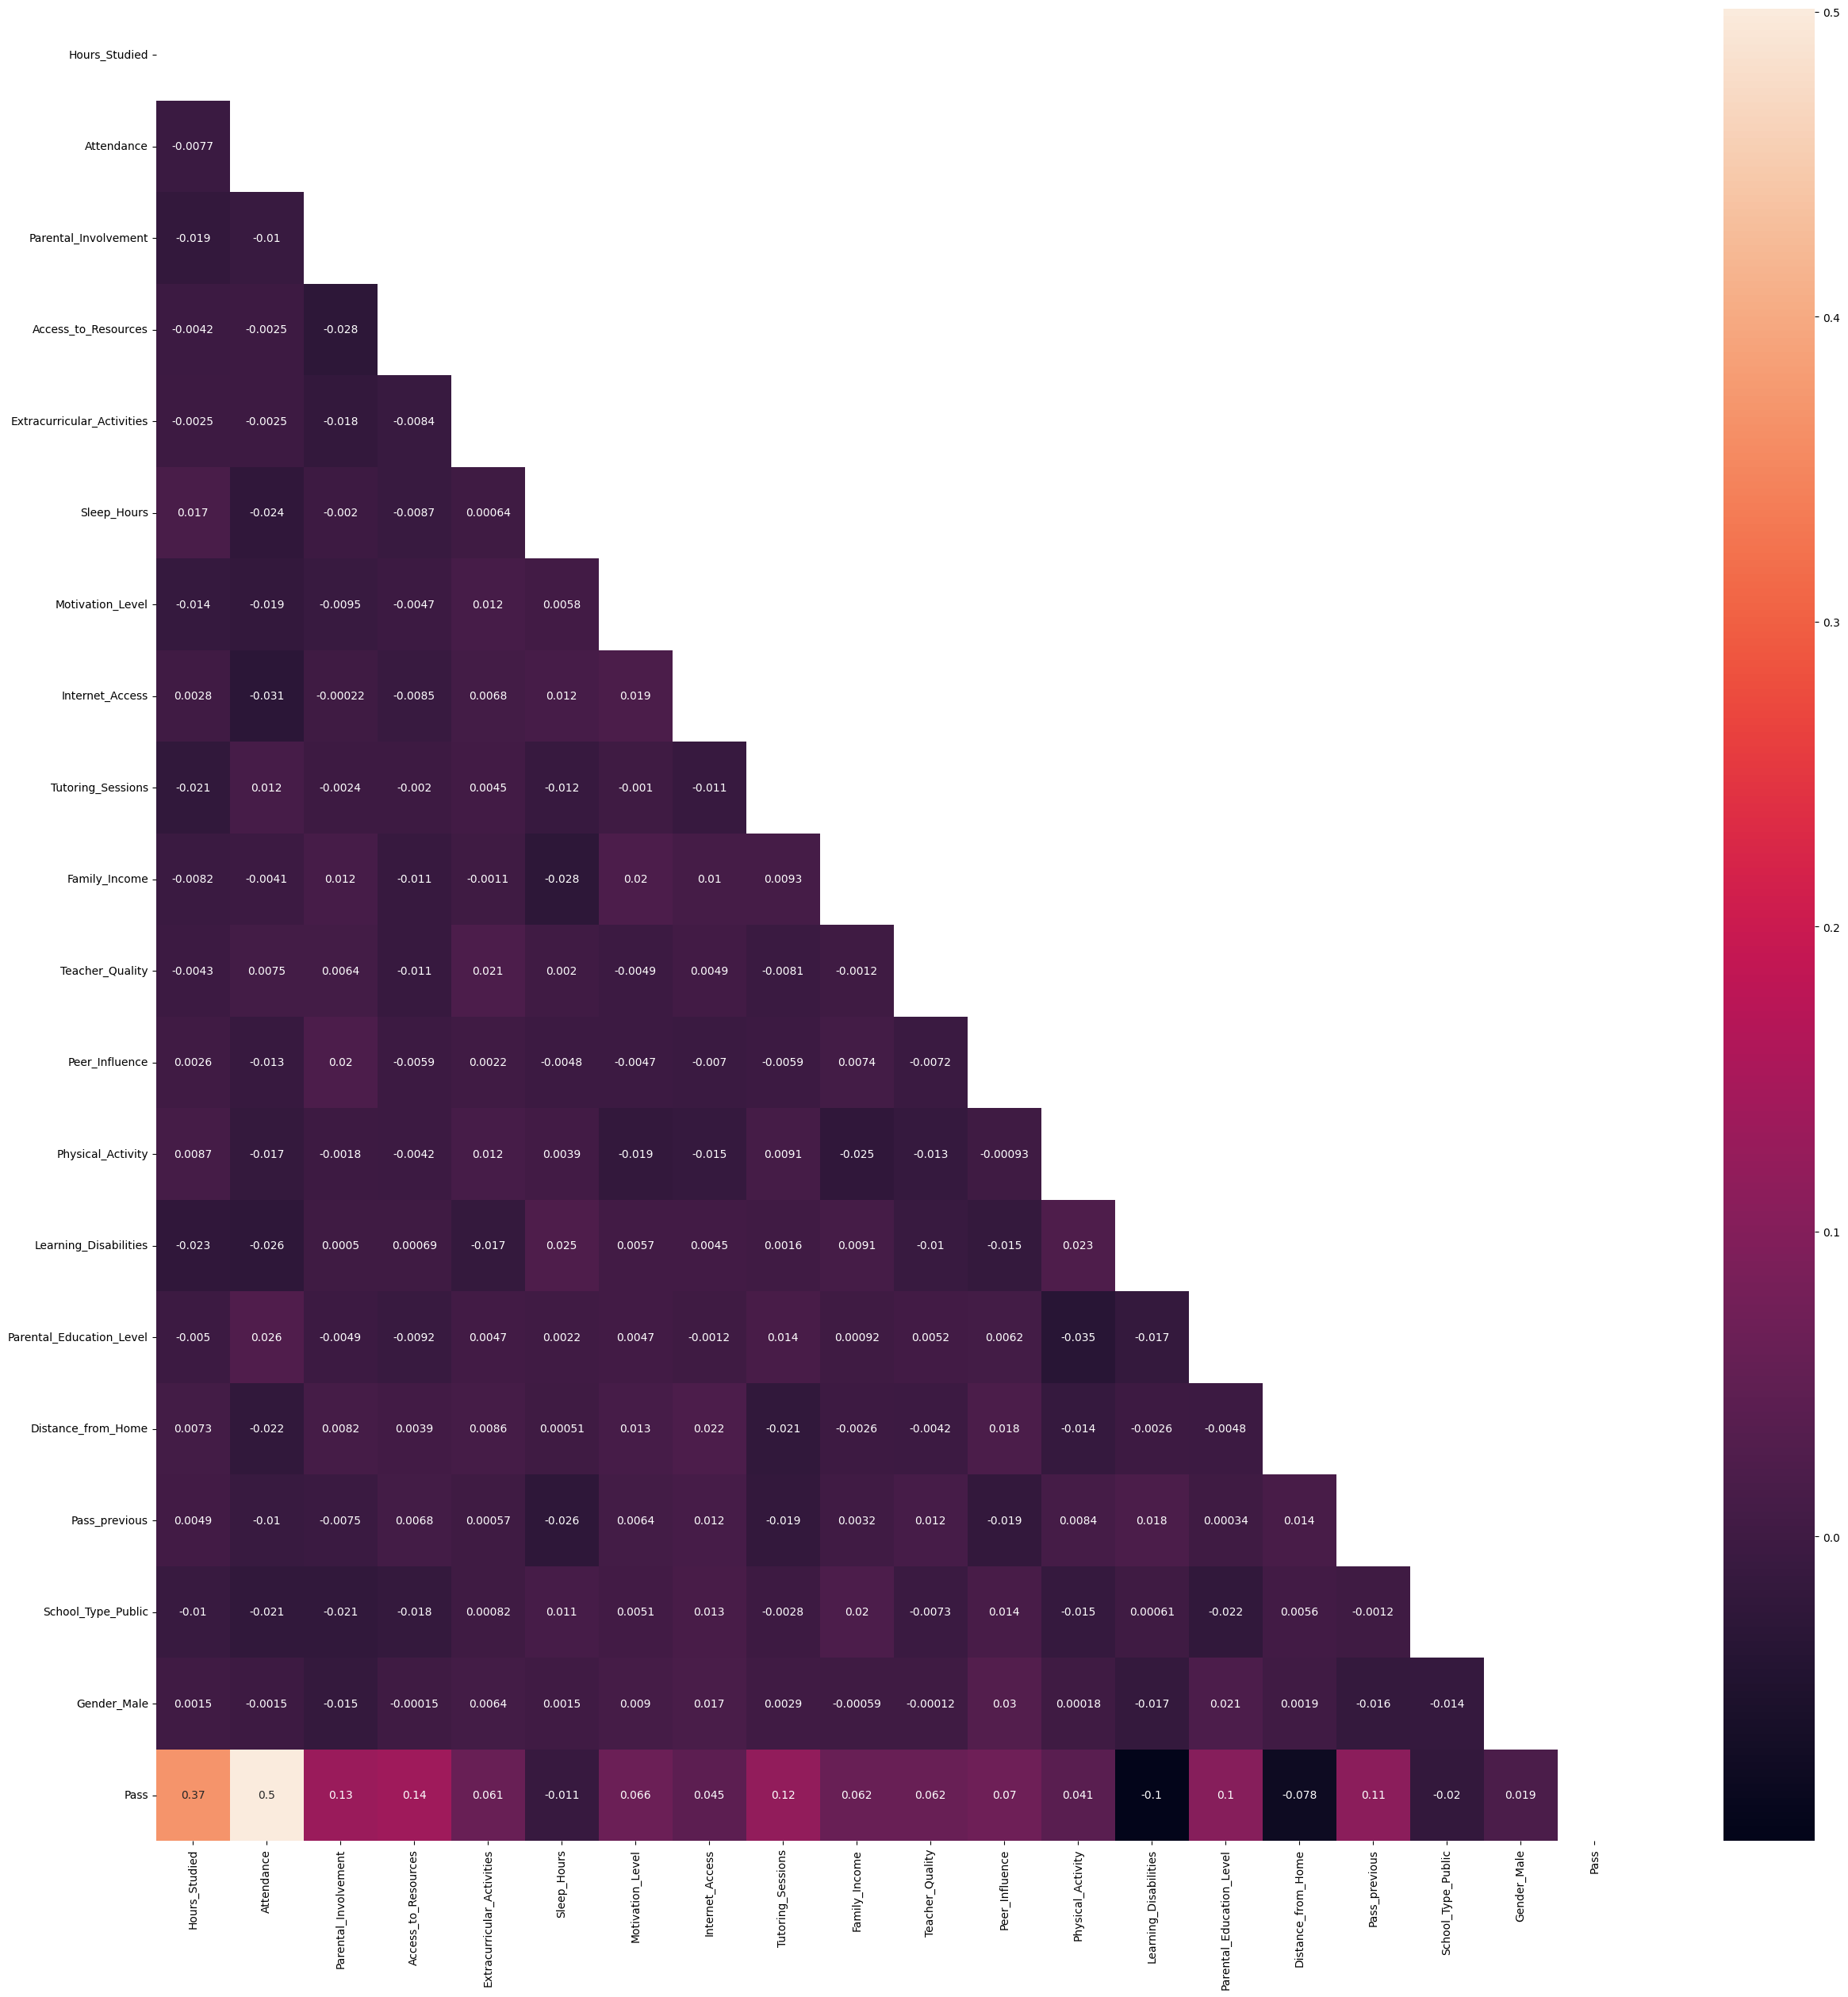

In [20]:
plt.subplots(figsize=(30,30))
mask = np.zeros_like(corr_df.corr(), dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_df.corr(),
            xticklabels=corr_df.corr().columns,
            yticklabels=corr_df.corr().columns,
            annot=True, mask=mask)
#plt.savefig('DiabetesCorrelationMatrix')
plt.show()

### Data Standardization

In [21]:
stan_cols = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Tutoring_Sessions',
    'Physical_Activity'
]

scaler = StandardScaler()

X_train[stan_cols] = scaler.fit_transform(X_train[stan_cols])
X_test[stan_cols] = scaler.transform(X_test[stan_cols])

X_train.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Pass_previous,School_Type_Public,Gender_Male
1020,0.508503,-1.202988,1.0,2.0,0,-0.705727,1.0,1,-1.217150,2.0,1.0,2.0,-0.929368,0,0.0,0.0,True,True,False
5244,1.008165,0.530283,0.0,0.0,0,0.665329,0.0,1,-1.217150,0.0,2.0,1.0,1.002267,0,0.0,0.0,True,True,False
6153,-0.823931,-0.769670,2.0,0.0,0,-0.705727,0.0,0,2.835927,0.0,1.0,2.0,1.002267,0,1.0,0.0,True,True,False
2805,-1.823256,-0.769670,0.0,2.0,1,-0.020199,1.0,1,-1.217150,0.0,1.0,0.0,-0.929368,0,0.0,0.0,True,True,True
737,1.008165,0.356956,0.0,2.0,0,-2.076784,1.0,0,1.214696,2.0,2.0,2.0,-0.929368,0,0.0,0.0,False,True,True


In [22]:
X_test.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Pass_previous,School_Type_Public,Gender_Male
743,0.008840,-0.769670,1.0,0.0,0,-0.020199,2.0,1,-0.406535,1.0,1.0,0.0,1.968085,0,0.0,0.0,True,True,True
5551,0.341949,-0.769670,1.0,0.0,1,-0.020199,0.0,1,0.404081,0.0,2.0,1.0,-0.929368,0,0.0,1.0,True,True,False
3442,0.175394,0.963601,2.0,1.0,1,-0.705727,2.0,1,-0.406535,1.0,1.0,2.0,0.036450,0,2.0,0.0,False,True,False
6571,-1.323593,0.963601,1.0,0.0,1,0.665329,0.0,1,-1.217150,0.0,0.0,2.0,1.002267,0,0.0,1.0,True,True,True
4204,0.175394,-1.462978,0.0,2.0,1,0.665329,1.0,1,0.404081,2.0,1.0,1.0,1.968085,0,0.0,0.0,True,True,True


In [23]:
y_train[:5]

,Pass
1020,True
5244,True
6153,False
2805,False
737,True


# Model Training

## Logistic Regression

### Logistic Regression Default Model

In [24]:
lg = LogisticRegression()
lg.fit(X_train, y_train)

LogisticRegression()

In [25]:
print(f"classes: {lg.classes_}\n")
print(f"number of features: {lg.n_features_in_}\n")
print(f"features: {lg.feature_names_in_}\n")
print(f"intercept: {lg.intercept_}\n")
print(f"coefficents: {lg.coef_}\n")

classes: [False  True]

number of features: 19

features: ['Hours_Studied' 'Attendance' 'Parental_Involvement' 'Access_to_Resources'
 'Extracurricular_Activities' 'Sleep_Hours' 'Motivation_Level'
 'Internet_Access' 'Tutoring_Sessions' 'Family_Income' 'Teacher_Quality'
 'Peer_Influence' 'Physical_Activity' 'Learning_Disabilities'
 'Parental_Education_Level' 'Distance_from_Home' 'Pass_previous'
 'School_Type_Public' 'Gender_Male']

intercept: [-9.72375164]

coefficents: [[ 4.51096204e+00  5.90894025e+00  2.57599488e+00  2.77659133e+00
   1.40030316e+00 -5.20217285e-03  1.36406214e+00  2.54810264e+00
   1.59208256e+00  1.18675838e+00  1.23550862e+00  1.29643106e+00
   6.10653292e-01 -2.42503261e+00  1.25136426e+00 -1.26600393e+00
   3.00595351e+00 -1.00487609e-01  2.63027671e-01]]



In [26]:
predictions = lg.predict(X_test)
passes = 0
fails = 0
for x in predictions:
  if x == 1:
    passes += 1
  else:
    fails += 1
print(f"the model predicts there are {passes} 1's and {fails} 0's in this test sample.")

the model predicts there are 1313 1's and 339 0's in this test sample.


In [27]:
accuracy_lg = lg.score(X_test, y_test)
print("accuracy =", round((accuracy_lg * 100), 4), "%")

accuracy = 96.3075 %


In [28]:
pred_lg = lg.predict(X_test)
print("Classification Report:\n", classification_report(y_test, pred_lg))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_lg))

Classification Report:
               precision    recall  f1-score   support

       False       0.92      0.90      0.91       346
        True       0.97      0.98      0.98      1306

    accuracy                           0.96      1652
   macro avg       0.95      0.94      0.94      1652
weighted avg       0.96      0.96      0.96      1652

Confusion Matrix:
 [[ 312   34]
 [  27 1279]]


### Logistic Regression Model Tuning

In [29]:
lg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [30]:
def tuned_logreg(X_train, y_train):
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [100, 500, 1000, 2000],
        'class_weight': [None,'balanced']
    }

    grid = GridSearchCV(
        lg,
        param_grid,
        cv=5,
        scoring='accuracy'
    )

    grid.fit(X_train, y_train)

    return grid.best_estimator_, grid.best_params_, grid.best_score_

lg_cv, best_params, best_score = tuned_logreg(X_train, y_train)

print("Best Model:", lg_cv)
print("Best Params:", best_params)
print("Best Score:", round((best_score * 100), 4), "%")

Best Model: LogisticRegression(C=100)
Best Params: {'C': 100, 'class_weight': None, 'max_iter': 100}
Best Score: 96.5893 %


In [31]:
accuracy_lg_cv = lg_cv.score(X_test, y_test)
print("Accuracy =", round((accuracy_lg_cv * 100), 4), "%")

Accuracy = 96.1864 %


In [32]:
pred_lg_cv = lg_cv.predict(X_test)
print("Classification Report:\n", classification_report(y_test, pred_lg_cv))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_lg_cv))

Classification Report:
               precision    recall  f1-score   support

       False       0.91      0.90      0.91       346
        True       0.97      0.98      0.98      1306

    accuracy                           0.96      1652
   macro avg       0.94      0.94      0.94      1652
weighted avg       0.96      0.96      0.96      1652

Confusion Matrix:
 [[ 313   33]
 [  30 1276]]


## KNN

### KNN Default Model

In [33]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
accuracy_knn = knn.score(X_test, y_test)
print(f"Accuracy = {round((accuracy_knn * 100), 4)}%")

Accuracy = 87.954%


In [35]:
pred_knn = knn.predict(X_test)
print("Classification Report:\n", classification_report(y_test, pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_knn))

Classification Report:
               precision    recall  f1-score   support

       False       0.80      0.56      0.66       346
        True       0.89      0.96      0.93      1306

    accuracy                           0.88      1652
   macro avg       0.85      0.76      0.79      1652
weighted avg       0.87      0.88      0.87      1652

Confusion Matrix:
 [[ 194  152]
 [  47 1259]]


### KNN Model Tuning

In [36]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [37]:
def tuned_knn(X_train, y_train):
  param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
  }

  grid = GridSearchCV(
      knn,
      param_grid,
      cv=5,
      scoring='accuracy',

  )

  grid.fit(X_train, y_train)

  return grid.best_estimator_, grid.best_params_, grid.best_score_

knn_cv, best_params, best_score = tuned_knn(X_train, y_train)

print("Best Model:", knn_cv)
print("Best Params:", best_params)
print("Best Score:", round((best_score * 100), 4), "%")

Best Model: KNeighborsClassifier(metric='euclidean', n_neighbors=10)
Best Params: {'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'uniform'}
Best Score: 89.5055 %


In [38]:
accuracy_knn_cv = knn_cv.score(X_test, y_test)
print("Accuracy =", round((accuracy_knn_cv * 100), 4), "%")

Accuracy = 90.1332 %


In [39]:
pred_knn_cv = knn_cv.predict(X_test)
print("Classification Report:\n", classification_report(y_test, pred_knn_cv))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_knn_cv))

Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.64      0.73       346
        True       0.91      0.97      0.94      1306

    accuracy                           0.90      1652
   macro avg       0.88      0.81      0.84      1652
weighted avg       0.90      0.90      0.90      1652

Confusion Matrix:
 [[ 223  123]
 [  40 1266]]


## Randon Forest

### Random Forest Default Model

In [40]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train);

In [41]:
!mkdir -p images

In [42]:
# Pull out one tree from the forest to a dot file and create a png file in drive
tree = rf.estimators_[3]
export_graphviz(tree, out_file = 'images/rf.dot', feature_names = feature_list, rounded = True, precision = 1)
(graph, ) = pydot.graph_from_dot_file('images/rf.dot')
graph.write_png('images/rf.png');
Image(filename='images/rf.png')

Output hidden; open in https://colab.research.google.com to view.

In [43]:
print('The depth of the tree is:', tree.tree_.max_depth)

The depth of the tree is: 19


In [44]:
accuracy_rf = rf.score(X_test, y_test)
print("accuracy =", round((accuracy_rf * 100), 4), "%")

accuracy = 91.1017 %


In [45]:
pred_rf = rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf))

Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.67      0.76       346
        True       0.92      0.97      0.95      1306

    accuracy                           0.91      1652
   macro avg       0.90      0.82      0.85      1652
weighted avg       0.91      0.91      0.91      1652

Confusion Matrix:
 [[ 232  114]
 [  33 1273]]


### Random Forest Model Tuning

In [46]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [47]:
def train_random_forest_cv(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': [None, 'balanced']
    }

    grid = GridSearchCV(
        rf,
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    return grid.best_estimator_, grid.best_params_, grid.best_score_

rf_cv, best_params, best_score = train_random_forest_cv(X_train, y_train)

print("Best Model:", rf_cv)
print("Best Params:", best_params)
print("Best Score:", round((best_score * 100), 4), "%")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Model: RandomForestClassifier(class_weight='balanced', max_depth=10,
                       max_features='log2', min_samples_split=4,
                       n_estimators=200)
Best Params: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 4, 'n_estimators': 200}
Best Score: 92.0081 %


In [48]:
tree_cv = rf_cv.estimators_[7]
print('The depth of the tuned tree is:', tree_cv.tree_.max_depth)

The depth of the tuned tree is: 10


In [49]:
accuracy_rf_cv = rf_cv.score(X_test, y_test)
print("Accuracy =", round((accuracy_rf_cv * 100), 4), "%")

Accuracy = 90.9806 %


In [50]:
pred_rf_cv = rf_cv.predict(X_test)

print("Classification Report:\n", classification_report(y_test, pred_rf_cv))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf_cv))

Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.80      0.79       346
        True       0.95      0.94      0.94      1306

    accuracy                           0.91      1652
   macro avg       0.86      0.87      0.87      1652
weighted avg       0.91      0.91      0.91      1652

Confusion Matrix:
 [[ 276   70]
 [  79 1227]]


### Featured Randon Forest

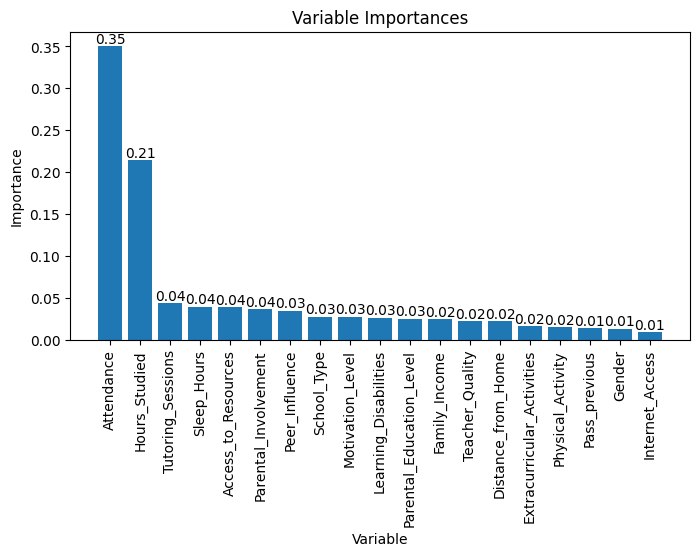

In [51]:
# Plot importance
importances = rf.feature_importances_

indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = np.array(feature_list)[indices]

plt.figure(figsize=(8,4))
bars = plt.bar(range(len(importances)), sorted_importances)

plt.xticks(range(len(importances)), sorted_features, rotation='vertical')
plt.ylabel('Importance')
plt.xlabel('Variable')
plt.title('Variable Importances')
plt.bar_label(bars, fmt="%.2f")

plt.show()

In [52]:
train_important = X_train[['Attendance', 'Hours_Studied']]
test_important = X_test[['Attendance', 'Hours_Studied']]

rf_featured = RandomForestClassifier()
rf_featured.fit(train_important, y_train)

RandomForestClassifier()

In [53]:
accuracy_rf_featured = rf_featured.score(test_important, y_test)
print("Accuracy =", round((accuracy_rf_featured * 100), 4), "%")

Accuracy = 84.3826 %


In [54]:
pred_rf_featured = rf_featured.predict(test_important)
print("Classification Report:\n", classification_report(y_test, pred_rf_featured))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf_featured))
# accuracy_score(y_test, pred_rf_featured)

Classification Report:
               precision    recall  f1-score   support

       False       0.64      0.58      0.61       346
        True       0.89      0.92      0.90      1306

    accuracy                           0.84      1652
   macro avg       0.77      0.75      0.75      1652
weighted avg       0.84      0.84      0.84      1652

Confusion Matrix:
 [[ 199  147]
 [ 111 1195]]


In [55]:
pred_proba_rf_featured = rf_featured.predict_proba(test_important)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test, pred_proba_rf_featured)
auc = round(metrics.roc_auc_score(y_test, pred_proba_rf_featured),4)
gini = round(((auc * 2) - 1),4)
label_string = f'AUC={auc}, Gini={gini}'
plt.plot(fpr, tpr, label=label_string)
plt.legend(loc=4)
plt.title('ROC curve', y=1.05)
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.show()

NameError: name 'metrics' is not defined

###

# Model Comparision

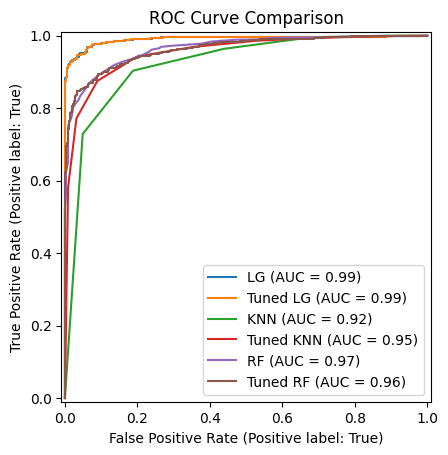

In [59]:
models = {
    "LG": lg,
    "Tuned LG": lg_cv,
    "KNN": knn,
    "Tuned KNN": knn_cv,
    "RF": rf,
    "Tuned RF": rf_cv,
}

ax = plt.gca()

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.title("ROC Curve Comparison")
plt.show()

In [56]:
baseline  = (X_test["Pass_previous"])

models = {
    "Baseline": baseline,
    "LG": pred_lg,
    "Tuned LG": pred_lg_cv,

    "KNN": pred_knn,
    "Tuned KNN": pred_knn_cv,

    "RF": pred_rf,
    "Tuned RF": pred_rf_cv,
    "Featured RF": pred_rf_featured
}

comparision = []

for name, value in models.items():
    comparision.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, value) * 100, 2),
        "Precision": round(precision_score(y_test, value) * 100, 2),
        "Recall": round(recall_score(y_test, value) * 100, 2)
    })

comparision = pd.DataFrame(comparision)
comparision

,Model,Accuracy,Precision,Recall
0,Baseline,67.62,82.15,75.42
1,LG,96.31,97.41,97.93
2,Tuned LG,96.19,97.48,97.70
3,KNN,87.95,89.23,96.40
4,Tuned KNN,90.13,91.14,96.94
5,RF,91.10,91.78,97.47
6,Tuned RF,90.98,94.60,93.95
7,Featured RF,84.38,89.05,91.50


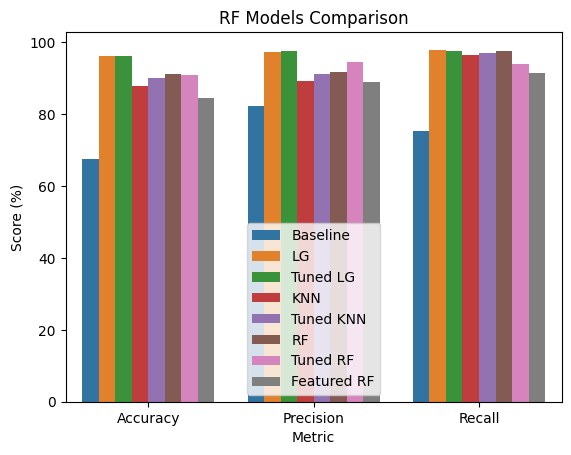

In [57]:
df_plot = comparision.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model')
plt.ylabel("Score (%)")
plt.title("RF Models Comparison")
plt.legend(loc='lower center')
plt.show()

In [58]:
metrics = ["Accuracy", "Precision", "Recall"]

baseline = comparision[comparision["Model"]=="Baseline"].iloc[0]

best_result_table = []

for m in metrics:
    best = comparision.loc[comparision[m].idxmax()]

    best_result_table.append({
        "Metric": m,
        "Best_Model": best["Model"],
        "Best_Score %": best[m],
        "Improvement %": round(best[m] - baseline[m], 2)
    })

df_results = pd.DataFrame(best_result_table)

df_results

,Metric,Best_Model,Best_Score %,Improvement %
0,Accuracy,LG,96.31,28.69
1,Precision,Tuned LG,97.48,15.33
2,Recall,LG,97.93,22.51
